In [1]:
# 5.8 Q3 - Chicago Taxi Fare Prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [3]:
df = pd.read_csv('datasets/chicago_taxi_sample.csv')
print("Shape:", df.shape)
print(df.head())
print()
print(df.dtypes)

Shape: (5000, 8)
   trip_seconds  trip_miles   fare  tips  tolls  extras  trip_total  \
0           142        4.80  15.50  2.09    1.0       1       19.59   
1          3703        2.11  18.90  0.22    0.0       0       19.12   
2          3226        1.23  14.97  0.98    0.0       0       15.95   
3           347        1.61   9.34  1.04    0.0       0       10.38   
4          4914        2.61  24.65  1.46    0.0       2       28.11   

  payment_type  
0         Cash  
1         Cash  
2  Credit Card  
3    No Charge  
4         Cash  

trip_seconds      int64
trip_miles      float64
fare            float64
tips            float64
tolls           float64
extras            int64
trip_total      float64
payment_type     object
dtype: object


In [4]:
print("Null values:")
print(df.isnull().sum())

Null values:
trip_seconds    0
trip_miles      0
fare            0
tips            0
tolls           0
extras          0
trip_total      0
payment_type    0
dtype: int64


In [5]:
# Feature engineering - one-hot encode payment_type

In [6]:
df_model = pd.get_dummies(df, columns=['payment_type'], drop_first=True)

y = df_model['fare']
feature_cols = [c for c in df_model.columns
                if c not in ('fare', 'tips', 'tolls', 'extras', 'trip_total')]
X = df_model[feature_cols]

print("Features:", feature_cols)
print("X shape:", X.shape, "y shape:", y.shape)

Features: ['trip_seconds', 'trip_miles', 'payment_type_Credit Card', 'payment_type_Mobile', 'payment_type_No Charge']
X shape: (5000, 5) y shape: (5000,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (4000, 5) Test: (1000, 5)


In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
for n, c in zip(feature_cols, model.coef_):
    print("  " + n.ljust(30), round(c, 4))

Intercept: 3.185424225120345
  trip_seconds                   0.0034
  trip_miles                     2.2506
  payment_type_Credit Card       -0.0356
  payment_type_Mobile            -0.1139
  payment_type_No Charge         -0.0675


In [9]:
y_pred = model.predict(X_test)
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
print("R2   :", r2)
print("RMSE :", rmse)
print("MAE  :", mae)

R2   : 0.942945126436472
RMSE : 1.5000469097667235
MAE  : 1.188832441320753


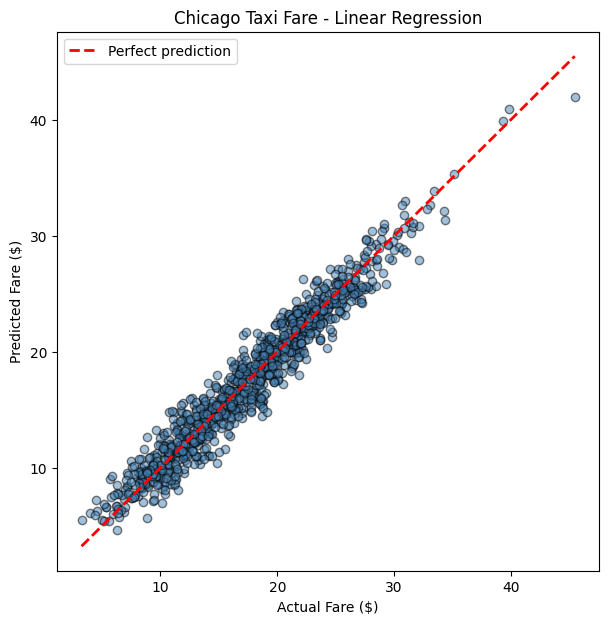

In [10]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='k')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Fare ($)')
plt.ylabel('Predicted Fare ($)')
plt.title('Chicago Taxi Fare - Linear Regression')
plt.legend()
plt.show()

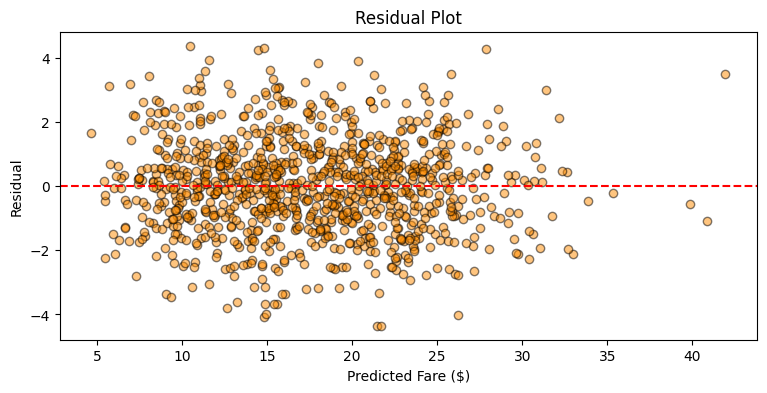

In [11]:
residuals = y_test - y_pred
plt.figure(figsize=(9, 4))
plt.scatter(y_pred, residuals, alpha=0.5, color='darkorange', edgecolors='k')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Fare ($)')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.show()